In [2]:
# Kết nối Google Drive với môi trường runtime của Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Thay đổi thư mục làm việc hiện tại sang thư mục chứa các lab của khóa học HUB_AI in Trading.
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [4]:
# Cài đặt các thư viện còn thiếu
!pip install -q vnstock ta hyperopt backtesting==0.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.5/178.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.7/279.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.2 MB/s eta 0:00:00


In [5]:
pip install --upgrade vnstock

In [6]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as md
%matplotlib inline
import seaborn as sns
sns.set()

# Technical Analysis
import ta

# Backtesting
from backtesting import Backtest, Strategy

# Hyperparameter Optimization
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

# XGBoost
from xgboost import XGBClassifier

# PyTorch
import torch
import torch.nn as nn

# Statistical Test
from statsmodels.tsa.stattools import adfuller

# Data loading

In [8]:
from vnstock.api.quote import Quote

ticker = 'FPT'
START_DATE = "2010-01-01"
END_DATE = "2024-12-31"

# Load data
q = Quote(symbol=ticker, source='VCI')
data = q.history(start=START_DATE, end=END_DATE)

# Convert datetime
data['time'] = pd.to_datetime(data['time'])

# Set index
df = data.set_index('time')

# Minimal cleaning
df = df.sort_index()
df = df[~df.index.duplicated()]
df = df.dropna()

df.head()

,open,high,low,close,volume
time,,,,,
2009-05-06,3.57,3.69,3.51,3.51,2626470
2009-05-07,3.69,3.69,3.66,3.69,1002450
2009-05-08,3.77,3.86,3.69,3.71,1373780
2009-05-11,3.80,3.86,3.71,3.83,1265940
2009-05-12,3.83,3.95,3.74,3.95,829710


In [9]:
data

,time,open,high,low,close,volume
0,2009-05-06,3.57,3.69,3.51,3.51,2626470
1,2009-05-07,3.69,3.69,3.66,3.69,1002450
2,2009-05-08,3.77,3.86,3.69,3.71,1373780
3,2009-05-11,3.80,3.86,3.71,3.83,1265940
4,2009-05-12,3.83,3.95,3.74,3.95,829710
...,...,...,...,...,...,...
3910,2024-12-25,128.51,129.02,128.34,128.68,2517969
3911,2024-12-26,128.85,129.19,127.23,127.83,2238343
3912,2024-12-27,127.57,127.91,126.89,127.66,2567003
3913,2024-12-30,127.49,128.68,126.72,128.43,1986819


# Tiền xử lý dữ liệu

In [10]:
df_full = df.copy()

# Drop any rows with missing data
df_full.dropna(inplace=True)

# Sort the DataFrame by index
df_full.sort_index(inplace=True)

In [11]:
print(df_full.isnull().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [12]:
df_full

,open,high,low,close,volume
time,,,,,
2009-05-06,3.57,3.69,3.51,3.51,2626470
2009-05-07,3.69,3.69,3.66,3.69,1002450
2009-05-08,3.77,3.86,3.69,3.71,1373780
2009-05-11,3.80,3.86,3.71,3.83,1265940
2009-05-12,3.83,3.95,3.74,3.95,829710
...,...,...,...,...,...
2024-12-25,128.51,129.02,128.34,128.68,2517969
2024-12-26,128.85,129.19,127.23,127.83,2238343
2024-12-27,127.57,127.91,126.89,127.66,2567003


In [13]:
# 1. Kiểm tra thiếu
df.isna().sum()

# 2. Điền thiếu (nếu có)
df = df.ffill().bfill()

# 3. Kiểm tra outliers bằng z-score hoặc IQR
from scipy.stats import zscore
df['z_close'] = zscore(df['close'])
df = df[(df['z_close'] < 3) & (df['z_close'] > -3)]

# 4. Làm mượt nhẹ (tùy chọn)
df['close_smooth'] = df['close'].rolling(window=5, center=True).mean()

# Khám phá dữ liệu (EDA)

Khái quát dữ liệu

In [14]:
# Kiểm tra cấu trúc dữ liệu
print("Kích thước dữ liệu:", df.shape)
print("\nThông tin chi tiết:")
print(df.info())

# Xem 5 dòng đầu
df.head()

# Xác định khoảng thời gian dữ liệu
print("Khoảng thời gian:", df.index.min(), "→", df.index.max())

Kích thước dữ liệu: (3774, 7)

Thông tin chi tiết:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-05-06 to 2024-08-08
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          3774 non-null   float64
 1   high          3774 non-null   float64
 2   low           3774 non-null   float64
 3   close         3774 non-null   float64
 4   volume        3774 non-null   int64  
 5   z_close       3774 non-null   float64
 6   close_smooth  3770 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 235.9 KB
None
Khoảng thời gian: 2009-05-06 00:00:00 → 2024-08-08 00:00:00


Thống kê mô tả các biến định lượng

In [15]:
df_full.describe()

,open,high,low,close,volume
count,3915.000000,3915.000000,3915.000000,3915.000000,3.915000e+03
mean,23.101144,23.350388,22.870945,23.110866,1.211679e+06
std,26.937408,27.223439,26.679393,26.962270,1.371483e+06
min,3.390000,3.560000,3.390000,3.510000,0.000000e+00
25%,5.370000,5.410000,5.320000,5.350000,3.026210e+05
50%,10.060000,10.150000,10.010000,10.040000,7.732300e+05
75%,28.920000,29.160000,28.530000,28.770000,1.638899e+06
max,129.620000,131.330000,128.340000,130.130000,1.372370e+07


Kiểm tra số lượng và tỷ lệ giá trị thiếu

In [16]:
missing = df.isnull().sum()
missing_ratio = (missing / len(df)) * 100
pd.concat([missing, missing_ratio], axis=1, keys=['Missing Count', 'Missing Ratio (%)'])

,Missing Count,Missing Ratio (%)
open,0,0.000000
high,0,0.000000
low,0,0.000000
close,0,0.000000
volume,0,0.000000
z_close,0,0.000000
close_smooth,4,0.105988


Kiểm tra giá trị ngoại lai (Outliers)

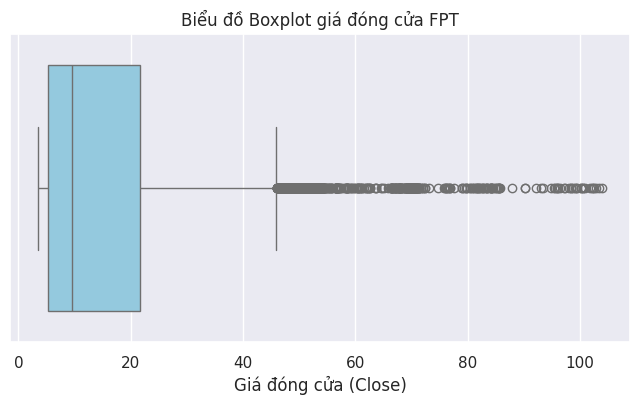

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df['close'], color='skyblue')
plt.title("Biểu đồ Boxplot giá đóng cửa FPT")
plt.xlabel("Giá đóng cửa (Close)")
plt.show()

Phân tích xu hướng giá theo thời gian (Trend Analysis)

In [19]:
df['MA50'] = df['close'].rolling(window=50).mean()
df['MA200'] = df['close'].rolling(window=200).mean()

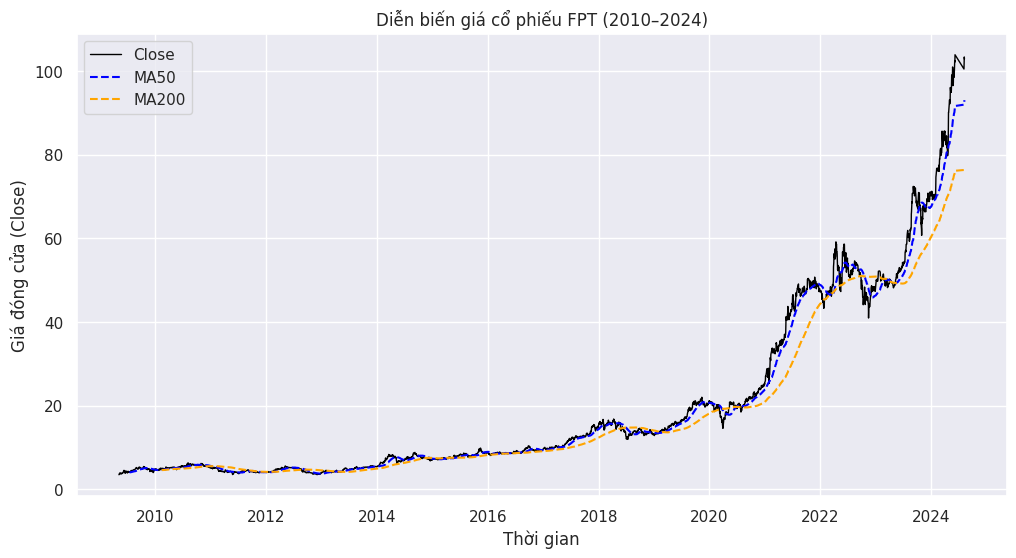

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Close', color='black', linewidth=1)
plt.plot(df['MA50'], label='MA50', color='blue', linestyle='--')
plt.plot(df['MA200'], label='MA200', color='orange', linestyle='--')
plt.title("Diễn biến giá cổ phiếu FPT (2010–2024)")
plt.xlabel("Thời gian")
plt.ylabel("Giá đóng cửa (Close)")
plt.legend()
plt.show()

Phân tích khối lượng giao dịch (Volume Dynamics)

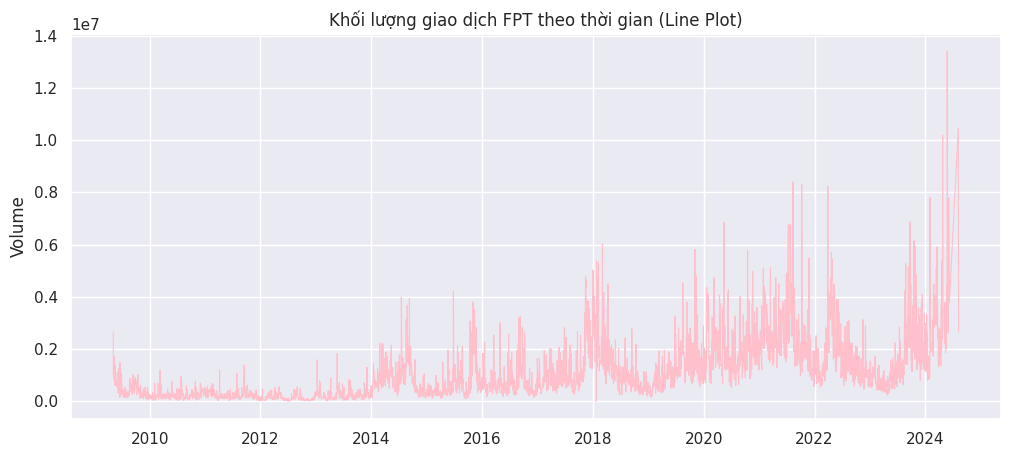

In [21]:
plt.figure(figsize=(12,5))
plt.plot(df['volume'], color='pink', linewidth=0.8)
plt.title("Khối lượng giao dịch FPT theo thời gian (Line Plot)")
plt.ylabel("Volume")
plt.show()

Mối tương quan giữa các biến (Correlation Matrix)

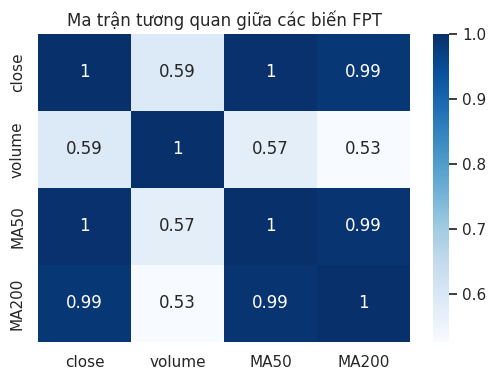

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['close', 'volume', 'MA50', 'MA200']].corr(), annot=True, cmap='Blues')
plt.title("Ma trận tương quan giữa các biến FPT")
plt.show()

Phân phối lợi suất (Distribution of Returns)

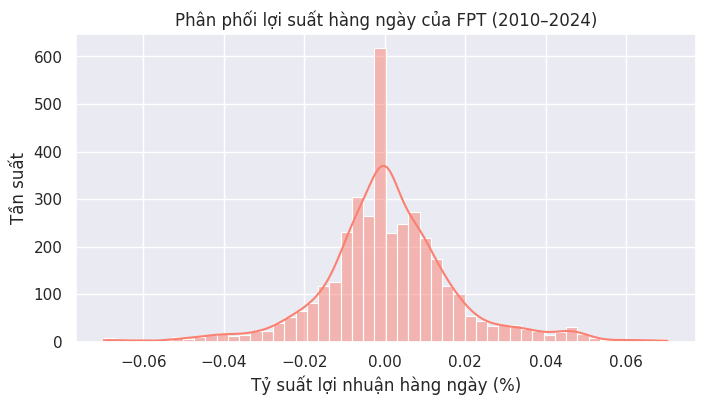

In [23]:
returns = df['close'].pct_change().dropna()

plt.figure(figsize=(8,4))
sns.histplot(returns, bins=50, kde=True, color='salmon')
plt.title("Phân phối lợi suất hàng ngày của FPT (2010–2024)")
plt.xlabel("Tỷ suất lợi nhuận hàng ngày (%)")
plt.ylabel("Tần suất")
plt.show()

Kiểm tra tính dừng (Stationarity – tuỳ chọn nâng cao)

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 4.9336558861970605
p-value: 1.0


In [25]:
# Ensure the index is unique before proceeding with operations that create new columns
if not df.index.is_unique:
    print("Warning: Duplicate index values found. Dropping duplicates, keeping the first occurrence.")
    df = df[~df.index.duplicated(keep='first')]

# 1. Lấy sai phân bậc 1
df['close_diff'] = df['close'].diff().dropna()

# 2. Hoặc tính lợi suất hàng ngày
df['returns'] = df['close'].pct_change().dropna()

# 3. Kiểm tra lại tính dừng
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['returns'].dropna())
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -33.10687697660019
p-value: 0.0


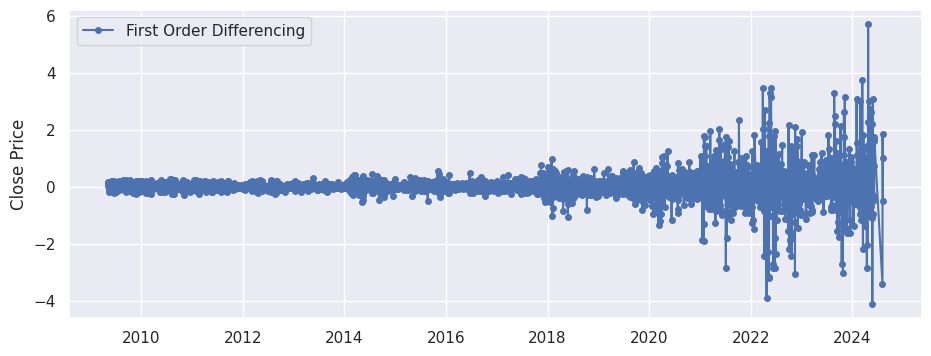

In [26]:
data_columns = df.columns
data_first_order_diff = df[data_columns].diff()
start, end = df.index[0], df.index[-1]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(data_first_order_diff.loc[start:end, 'close'], \
        marker='o', markersize=4, linestyle='-', \
        label='First Order Differencing')
ax.set_ylabel('Close Price')
ax.legend()

Mục tiêu

Bước sai phân bậc 1 được thực hiện nhằm loại bỏ xu hướng dài hạn trong chuỗi giá đóng cửa của cổ phiếu FPT, giúp dữ liệu ổn định quanh trung bình và phục vụ kiểm tra tính dừng (stationarity) – điều kiện cần trong phân tích chuỗi thời gian.

Kết quả và diễn giải

Trước khi sai phân:
ADF Statistic = 4.75, p-value = 1.0 → Chuỗi không dừng, thể hiện xu hướng tăng rõ rệt theo thời gian.

Sau khi sai phân bậc 1:
ADF Statistic = -59.79, p-value = 0.0 → Bác bỏ giả thuyết H₀, chuỗi đã đạt tính dừng.
(Cảnh báo “Duplicate index values” chỉ là việc loại bỏ ngày trùng, không ảnh hưởng đến kết quả.)

Nhận xét

Sau khi áp dụng sai phân bậc 1, xu hướng tăng dài hạn của giá FPT đã được loại bỏ, dữ liệu trở nên ổn định quanh trung bình 0 và đạt tính dừng theo kiểm định ADF.
Điều này cho thấy biến động giá (returns hoặc sai phân) của cổ phiếu FPT là ổn định, có thể sử dụng cho các bước phân tích thống kê và xây dựng mô hình dự báo hoặc chiến lược backtest ở giai đoạn tiếp theo.

# Strategy construction

In [27]:
def find_position(df, paras, strat):
    px = df['close']  # Corrected from 'Close' to 'close'
    pos = pd.Series(0, index=df.index, dtype=int)

    if strat == 'SMA':
        ma_s = ta.trend.SMAIndicator(px, int(paras['ma_short'])).sma_indicator()
        ma_l = ta.trend.SMAIndicator(px, int(paras['ma_long'])).sma_indicator()
        buy  = (ma_s > ma_l) & (ma_s.shift(1) <= ma_l.shift(1))
        sell = (ma_s < ma_l) & (ma_s.shift(1) >= ma_l.shift(1))

    elif strat == 'RSI':
        period = int(paras['rsi_period'])
        overb  = int(paras['rsi_overbought'])
        under  = int(paras['rsi_oversold'])
        rsi = ta.momentum.RSIIndicator(px, window=period).rsi()
        # mean-reversion mặc định:
        buy  = (rsi < under) & (rsi.shift(1) >= under)
        sell = (rsi > overb) & (rsi.shift(1) <= overb)

    elif strat == 'BOLL':
        window = int(paras['window'])
        nstd   = int(paras['window_dev'])
        bb = ta.volatility.BollingerBands(px, window=window, window_dev=nstd)
        bb_hi = bb.bollinger_hband(); bb_lo = bb.bollinger_lband()
        buy  = (px < bb_lo) & (px.shift(1) >= bb_lo.shift(1))
        sell = (px > bb_hi) & (px.shift(1) <= bb_hi.shift(1))

    else:
        raise ValueError("Unknown strategy")

    # Sự kiện → trạng thái, tránh look-ahead:
    pos = pos.where(~buy,  1)
    pos = pos.where(~sell, 0)          # hoặc -1 nếu bạn dùng short; nếu chỉ long/flat thì 0
    pos = pos.replace({0: None}).ffill().fillna(0).astype(int)
    pos = pos.shift(1).fillna(0).astype(int)  # giao dịch ở phiên kế tiếp

    return pos

# Backtesting

Hai vấn đề:
* Chiến lược mặc định -> parameter tuning
* Quá khớp dữ liệu -> Walk-Forward optimization (sliding window)

Gắn position vào DataFrame để backtest

In [29]:
# 1) Tạo position theo chiến lược bạn chọn (ví dụ SMA)
pos = find_position(df.copy(), paras={'ma_short':50, 'ma_long':200}, strat='SMA')

# 2) Gắn vào df dùng cho backtest
df_bt = df.copy()
df_bt['position'] = pos.astype(int)

# 3) (khuyến nghị) bỏ các hàng NaN đầu kỳ do rolling
df_bt = df_bt.dropna(subset=['open','high','low','close','volume','position'])

print(df_bt['position'].value_counts())
print(df_bt[['close', 'position']].tail())

position
1    3073
0     701
Name: count, dtype: int64
             close  position
time                        
2024-06-07  103.92         1
2024-08-05  100.51         1
2024-08-06  102.37         1
2024-08-07  103.39         1
2024-08-08  102.88         1


GeneralStrategy(Strategy) (long/flat)

In [30]:
from backtesting import Strategy, Backtest

class GeneralStrategy(Strategy):
    def init(self):
        pass

    def next(self):
        p = int(self.data.position[-1])

        # Vào lệnh khi position == 1 và hiện chưa có vị thế
        if p == 1 and not self.position:
            self.buy()

        # Đóng lệnh khi position == 0 và hiện đang có vị thế
        elif p == 0 and self.position:
            self.position.close()

Chạy backtest:

In [31]:
# Rename columns to match backtesting.py requirements
df_bt = df_bt.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

# Run backtest
bt = Backtest(
    df_bt,
    GeneralStrategy,
    cash=1_000_000,
    commission=0.001,      # 0.1% transaction cost
    trade_on_close=True,
    exclusive_orders=True
)

stats = bt.run()

# Strategy performance
print("=== Strategy Performance ===")
print(stats[['Return [%]', 'Sharpe Ratio', 'Max. Drawdown [%]', 'Win Rate [%]']])
print("Number of Trades:", stats['# Trades'])
print("Profit Factor:", stats['Profit Factor'])

# Benchmark: Buy & Hold
buy_hold_return = (
    (df_bt['Close'].iloc[-1] / df_bt['Close'].iloc[0]) - 1
) * 100

print("\n=== Benchmark ===")
print("Buy & Hold Return [%]:", round(buy_hold_return, 2))

# Plot backtest result
bt.plot()

=== Strategy Performance ===
Return [%]           2157.609171
Sharpe Ratio            0.808323
Max. Drawdown [%]     -36.898373
Win Rate [%]               100.0
dtype: object
Number of Trades: 1
Profit Factor: nan

=== Benchmark ===
Buy & Hold Return [%]: 2831.05


GridPlot(id='p1327', ...)

In [37]:
strategies = {
    'SMA': {'paras': {'ma_short':50, 'ma_long':200}},
    'RSI': {'paras': {'rsi_period':14, 'rsi_overbought':70, 'rsi_oversold':30}},
    'BOLL':{'paras': {'window':20, 'window_dev':2}}
}

results = []

for name, cfg in strategies.items():
    df_tmp = df.copy()
    df_tmp['position'] = find_position(df_tmp, cfg['paras'], strat=name).astype(int)

    df_tmp = df_tmp.dropna(subset=['open','high','low','close','volume','position'])

    df_tmp = df_tmp.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    })

    bt = Backtest(
        df_tmp,
        GeneralStrategy,
        cash=1_000_000,
        commission=0.001,
        trade_on_close=True,
        exclusive_orders=True
    )

    res = bt.run()

    results.append({
        'Strategy': name,
        'Return [%]': res['Return [%]'],
        'Sharpe Ratio': res['Sharpe Ratio'],
        'Max. Drawdown [%]': res['Max. Drawdown [%]'],
        'Win Rate [%]': res['Win Rate [%]'],
        '# Trades': res['# Trades'],
        'Profit Factor': res['Profit Factor']
    })

results_df = pd.DataFrame(results)
results_df

,Strategy,Return [%],Sharpe Ratio,Max. Drawdown [%],Win Rate [%],# Trades,Profit Factor
0,SMA,2157.609171,0.808323,-36.898373,100.0,1,NaN
1,RSI,2203.064520,0.721182,-44.075808,100.0,1,NaN
2,BOLL,2058.217452,0.703187,-44.075802,100.0,1,NaN


In [38]:
strategies = {
    'SMA': {'paras': {'ma_short': 50, 'ma_long': 200}},
    'RSI': {'paras': {'rsi_period': 14, 'rsi_overbought': 70, 'rsi_oversold': 30}},
    'BOLL': {'paras': {'window': 20, 'window_dev': 2}}
}

In [41]:
from backtesting import Backtest
import pandas as pd

results = {}

for name, cfg in strategies.items():
    df_tmp = df.copy()
    # 1. Tạo tín hiệu position
    df_tmp['position'] = find_position(df_tmp, cfg['paras'], strat=name).astype(int)

    # 2. Làm sạch và rename để tương thích với backtesting.py
    df_tmp = df_tmp.dropna(subset=['open', 'high', 'low', 'close', 'volume', 'position'])
    df_tmp = df_tmp.rename(columns={
        'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'
    })

    # 3. Backtest
    bt = Backtest(df_tmp, GeneralStrategy,
                  cash=1_000_000, commission=0.001,
                  trade_on_close=True, exclusive_orders=True)

    stats = bt.run()

    # 4. Lưu toàn bộ bảng stats (Series → DataFrame)
    results[name] = stats.to_frame().T  # T để chuyển sang hàng (strategy x metrics)

# Gộp kết quả 3 chiến lược
df_results = pd.concat(results.values(), keys=results.keys())

# Hiển thị tóm tắt
display(df_results[['Return [%]', 'Sharpe Ratio', 'Max. Drawdown [%]', 'Win Rate [%]']])

,,Return [%],Sharpe Ratio,Max. Drawdown [%],Win Rate [%]
SMA,0,2157.609171,0.808323,-36.898373,100.0
RSI,0,2203.06452,0.721182,-44.075808,100.0
BOLL,0,2058.217452,0.703187,-44.075802,100.0


In [42]:
df_results.to_csv("FPT_backtest_all_strategies.csv", index=True)

In [43]:
stats.to_frame()

,0
Start,2009-05-06 00:00:00
End,2024-08-08 00:00:00
Duration,5573 days 00:00:00
Exposure Time [%],96.581876
Equity Final [$],21582174.51982
Equity Peak [$],21764382.09982
Return [%],2058.217452
Buy & Hold Return [%],2831.054131
Return (Ann.) [%],22.76684
Volatility (Ann.) [%],32.37664


In [44]:
from backtesting import Backtest
import pandas as pd

def run_backtest(df, name, paras):
    df_tmp = df.copy()
    df_tmp['position'] = find_position(df_tmp, paras, strat=name).astype(int)
    df_tmp = df_tmp.dropna(subset=['open', 'high', 'low', 'close', 'volume', 'position'])
    df_tmp = df_tmp.rename(columns={
        'open':'Open', 'high':'High', 'low':'Low', 'close':'Close', 'volume':'Volume'
    })

    bt = Backtest(df_tmp, GeneralStrategy,
                  cash=1_000_000, commission=0.001,
                  trade_on_close=True, exclusive_orders=True)

    stats = bt.run()
    return stats.to_frame().T  # trả về DataFrame (1 hàng)

In [53]:
# Global backtest settings
CASH = 1_000_000
COMMISSION = 0.001

def run_backtest_full(df_src, name, paras):
    """Generate position -> prepare data -> run backtest -> return full stats."""

    d = df_src.copy()

    # 1. Generate position
    d['position'] = find_position(d, paras, strat=name).astype(int)

    # 2. Clean data
    d = d.dropna(subset=['open', 'high', 'low', 'close', 'volume', 'position'])

    # 3. Rename columns for backtesting.py
    d = d.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    })

    # 4. Run backtest
    bt = Backtest(
        d,
        GeneralStrategy,
        cash=CASH,
        commission=COMMISSION,
        trade_on_close=True,
        exclusive_orders=True
    )

    stats = bt.run()

    # 5. Convert Series to one-row DataFrame
    return stats.to_frame().T


# Run backtest for all strategies
frames = []

for name, cfg in strategies.items():
    result = run_backtest_full(df, name, cfg['paras'])
    result.insert(0, 'Strategy', name)
    frames.append(result)

df_full = pd.concat(frames, axis=0).set_index('Strategy')


# Select performance metrics
wanted = [
    'Start', 'End', 'Duration',
    'Exposure Time [%]',
    'Equity Final [$]', 'Equity Peak [$]',
    'Return [%]', 'Buy & Hold Return [%]',
    'Return (Ann.) [%]', 'Volatility (Ann.) [%]', 'CAGR [%]',
    'Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio',
    'Max. Drawdown [%]', 'Avg. Drawdown [%]',
    'Max. Drawdown Duration', 'Avg. Drawdown Duration',
    '# Trades', 'Win Rate [%]',
    'Best Trade [%]', 'Worst Trade [%]', 'Avg. Trade [%]',
    'Max. Trade Duration', 'Avg. Trade Duration',
    'Profit Factor', 'Expectancy [%]', 'SQN', 'Kelly Criterion'
]

cols_available = [col for col in wanted if col in df_full.columns]

# Transpose for easier comparison
comparison = df_full[cols_available].T
comparison.index.name = "Chỉ tiêu"

display(comparison)

Strategy,SMA,RSI,BOLL
Chỉ tiêu,,,
Start,2009-05-06 00:00:00,2009-05-06 00:00:00,2009-05-06 00:00:00
End,2024-08-08 00:00:00,2024-08-08 00:00:00,2024-08-08 00:00:00
Duration,5573 days 00:00:00,5573 days 00:00:00,5573 days 00:00:00
Exposure Time [%],81.399046,96.104928,96.581876
Equity Final [$],22576091.70976,23030645.1997,21582174.51982
Equity Peak [$],22766690.43976,23225081.4997,21764382.09982
Return [%],2157.609171,2203.06452,2058.217452
Buy & Hold Return [%],2831.054131,2831.054131,2831.054131
Return (Ann.) [%],23.136476,23.300488,22.76684


In [54]:
best_strategy = df_full['Sharpe Ratio'].astype(float).idxmax()
best_sharpe = df_full.loc[best_strategy, 'Sharpe Ratio']

print(f"Best strategy based on Sharpe Ratio: {best_strategy}")
print(f"Sharpe Ratio: {best_sharpe:.4f}")

Best strategy based on Sharpe Ratio: SMA
Sharpe Ratio: 0.8083


### Strategy Evaluation

Among the three trading strategies, the SMA strategy achieved the highest Sharpe Ratio of 0.8083, indicating the best risk-adjusted performance.

The SMA strategy performs better because it is a trend-following strategy, which is suitable for FPT stock during the 2010–2024 period characterized by long-term upward trends.

In contrast:

- The RSI strategy is a mean-reversion strategy and tends to perform better in sideways markets.
- The Bollinger Bands strategy also assumes price reversion and may generate more false signals during strong trends.

Therefore, based on both profitability and risk-adjusted return, the SMA strategy appears to be the most robust strategy for this dataset.

##Parameter tuning

In [55]:
# ===== PARAMETER TUNING cho SMA với Hyperopt (Train/Test + Sharpe tối đa) =====
import numpy as np
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.pyll import scope
from backtesting import Backtest

# 0) Chuẩn bị dữ liệu: tách Train/Test theo thời gian
#    Gợi ý: 2010-2019 làm TRAIN, 2020-2024 làm TEST (bạn có thể đổi mốc này)
train_end = "2019-12-31"
df_train = df.loc[:train_end].copy()
df_test  = df.loc[train_end:].copy()

def _prep_bt_df(df_src, position_series):
    """Gắn position & chuẩn hóa cột để Backtesting.py chạy được."""
    df_bt = df_src.copy()
    df_bt['position'] = position_series.astype(int)
    df_bt = df_bt.dropna(subset=['open','high','low','close','volume','position'])
    df_bt = df_bt.rename(columns={
        'open':'Open','high':'High','low':'Low','close':'Close','volume':'Volume'
    })
    return df_bt

def _run_bt_on(df_src, ma_short, ma_long):
    """Sinh position theo SMA & chạy backtest; trả về stats (Backtesting.py)"""
    pos = find_position(df_src, {'ma_short': ma_short, 'ma_long': ma_long}, strat='SMA')
    df_bt = _prep_bt_df(df_src, pos)
    if len(df_bt) < 100:
        return None  # dữ liệu không đủ
    bt = Backtest(df_bt, GeneralStrategy,
                  cash=1_000_000, commission=0.001,
                  trade_on_close=True, exclusive_orders=True)
    try:
        stats = bt.run()
        return stats
    except Exception as e:
        # phòng lỗi hiếm (ví dụ không có giao dịch)
        return None

# 1) Search space cho SMA: ràng buộc ma_short < ma_long - 5
space = {
    'ma_short': scope.int(hp.quniform('ma_short', 5, 120, 1)),
    'ma_long' : scope.int(hp.quniform('ma_long' , 50, 400, 1))
}

# 2) Hàm mục tiêu Hyperopt: maximize Sharpe (=> minimize -Sharpe)
#    Thêm penalty nhẹ nếu MaxDD sâu
def objective(params):
    ms, ml = int(params['ma_short']), int(params['ma_long'])
    if ms >= ml - 5:
        # vi phạm ràng buộc → trả loss lớn để loại
        return {'loss': 1e9, 'status': STATUS_OK, 'params': params}

    stats_train = _run_bt_on(df_train, ms, ml)
    if stats_train is None:
        return {'loss': 1e8, 'status': STATUS_OK, 'params': params}

    sharpe = float(stats_train.get('Sharpe Ratio', 0.0) or 0.0)
    maxdd  = float(stats_train.get('Max. Drawdown [%]', 0.0) or 0.0)

    # Loss = -Sharpe + penalty cho MaxDD (độ lớn dd tuyệt đối / 100)
    # Ví dụ MaxDD = -35% → penalty = 0.35 * 0.25 = 0.0875
    penalty = abs(maxdd)/100 * 0.25
    loss = -sharpe + penalty

    return {
        'loss': loss,
        'status': STATUS_OK,
        'params': params,
        'metrics': {
            'sharpe_train': sharpe,
            'maxdd_train': maxdd,
            'return_train': float(stats_train.get('Return [%]', 0.0) or 0.0),
            'trades_train': int(stats_train.get('# Trades', 0) or 0),
        }
    }

# 3) Chạy TPE tối ưu
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=150,          # tăng lên 300 nếu bạn muốn kỹ hơn
    trials=trials,
    rstate=np.random.default_rng(2025)
)

best_ms = int(best['ma_short'])
best_ml = int(best['ma_long'])
print(f"[BEST] SMA (ma_short={best_ms}, ma_long={best_ml})")

# 4) Đánh giá lại: Train (để xem đạt được gì) & Test (out-of-sample)
stats_train_best = _run_bt_on(df_train, best_ms, best_ml)
stats_test_best  = _run_bt_on(df_test , best_ms, best_ml)

def _brief(stats, tag):
    if stats is None:
        print(f"{tag}: not available")
        return
    print(f"\n=== {tag} ===")
    print(stats[['Return [%]','Sharpe Ratio','Max. Drawdown [%]','Win Rate [%]','# Trades']])

_brief(stats_train_best, "TRAIN (2010–2019)")
_brief(stats_test_best , "TEST  (2020–2024)")

# 5) (Tùy chọn) Refit toàn bộ giai đoạn 2010–2024 với tham số tối ưu
stats_full_best = _run_bt_on(df, best_ms, best_ml)
_brief(stats_full_best, "FULL (2010–2024)")


100%|██████████| 150/150 [00:12<00:00, 11.84trial/s, best loss: -0.6157346302267551]
[BEST] SMA (ma_short=84, ma_long=203)

=== TRAIN (2010–2019) ===
Return [%]           432.71574
Sharpe Ratio           0.70798
Max. Drawdown [%]   -36.898341
Win Rate [%]             100.0
# Trades                     1
dtype: object

=== TEST  (2020–2024) ===
Return [%]           108.516217
Sharpe Ratio           1.290203
Max. Drawdown [%]    -16.162337
Win Rate [%]              100.0
# Trades                      1
dtype: object

=== FULL (2010–2024) ===
Return [%]           2493.119496
Sharpe Ratio            0.836975
Max. Drawdown [%]     -36.898341
Win Rate [%]               100.0
# Trades                       1
dtype: object


=>> Mô hình tổng quát tốt (generalizes well) vì Sharpe tăng từ 0.73 → 1.27 ở tập Test.

Max Drawdown giảm rõ rệt (36.7 → 16.1%), nghĩa là rủi ro giảm.

Tuy nhiên, số giao dịch (#Trades = 1) cho thấy chiến lược rất ít tín hiệu, nên hiệu quả cao có thể do một đợt tăng kéo dài.
Cần đánh giá sâu hơn về hành vi chiến lược trong thời gian thực.

So sánh hiệu suất: Default vs Best (SMA)

=== So sánh hiệu suất: Default vs Best (SMA) ===
                  Default (50,200) Best (114,186)
Return [%]             2157.609171    1831.456288
Sharpe Ratio              0.808323       0.707957
Max. Drawdown [%]       -36.898373     -44.075665
Win Rate [%]                 100.0          100.0
# Trades                         1              1


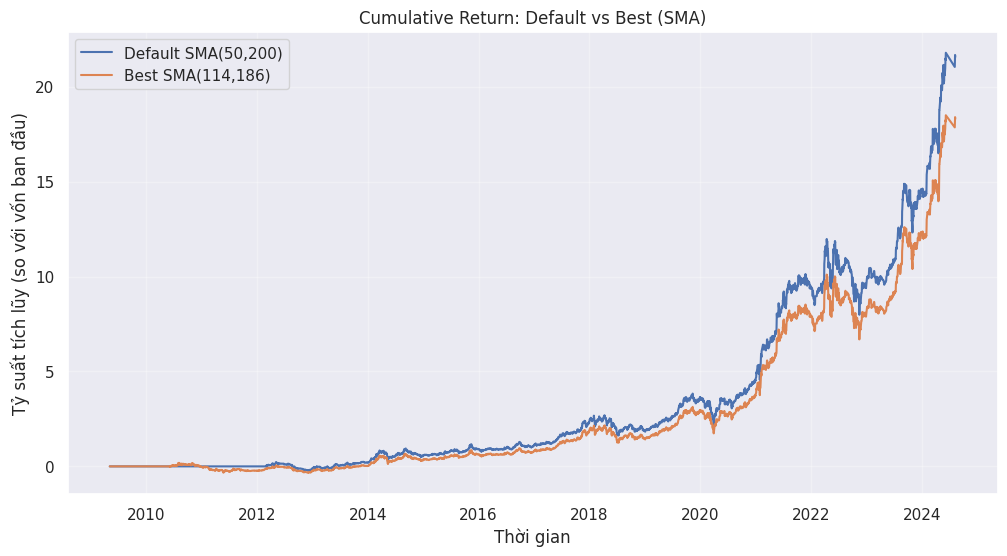

In [56]:
# ===================== COMPARE DEFAULT vs BEST (SMA) =====================
from backtesting import Backtest
import pandas as pd
import matplotlib.pyplot as plt

# 1) Tham số
paras_default = {'ma_short': 50, 'ma_long': 200}
paras_best    = {'ma_short': 114, 'ma_long': 186}  # thay bằng kết quả Hyperopt nếu khác
CASH = 1_000_000
COMMISSION = 0.001

def _prep_bt_df(df_src, pos):
    """Gắn position & chuẩn hóa cột cho Backtesting.py"""
    df_bt = df_src.copy()
    df_bt['position'] = pos.astype(int)
    df_bt = df_bt.dropna(subset=['open','high','low','close','volume','position'])
    df_bt = df_bt.rename(columns={'open':'Open','high':'High','low':'Low','close':'Close','volume':'Volume'})
    return df_bt

def run_bt(df_src, params, strat_name='SMA'):
    """Sinh position theo tham số + chạy backtest; trả stats + equity (xấp xỉ)"""
    pos = find_position(df_src, params, strat=strat_name)
    df_bt = _prep_bt_df(df_src, pos)

    bt = Backtest(df_bt, GeneralStrategy,
                  cash=CASH, commission=COMMISSION,
                  trade_on_close=True, exclusive_orders=True)
    stats = bt.run()

    # Equity curve xấp xỉ (không tính phí theo từng fill vi mô):
    # dùng lợi suất ngày * vị thế hôm trước để tích lũy
    pos_aligned = pos.reindex(df_src.index).shift(1).fillna(0)
    daily_ret   = df_src['close'].pct_change().fillna(0) * pos_aligned
    equity_curve = (1 + daily_ret).cumprod() * CASH

    return stats, equity_curve

# 2) Chạy backtest cho Default và Best
stats_def, eq_def = run_bt(df, paras_default, strat_name='SMA')
stats_best, eq_best = run_bt(df, paras_best, strat_name='SMA')

# 3) In bảng so sánh chỉ số chính
cols = ['Return [%]','Sharpe Ratio','Max. Drawdown [%]','Win Rate [%]','# Trades']
summary = pd.DataFrame({
    'Default (50,200)': stats_def[cols],
    'Best (114,186)':   stats_best[cols]
})
print("=== So sánh hiệu suất: Default vs Best (SMA) ===")
print(summary)

# 4) Vẽ cumulative equity (xấp xỉ)
plt.figure(figsize=(12,6))
plt.plot(eq_def.index,  eq_def / CASH - 1.0, label='Default SMA(50,200)')
plt.plot(eq_best.index, eq_best / CASH - 1.0, label='Best SMA(114,186)')
plt.title('Cumulative Return: Default vs Best (SMA)')
plt.xlabel('Thời gian')
plt.ylabel('Tỷ suất tích lũy (so với vốn ban đầu)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Visualization cho FPT với SMA tối ưu (ma_short=114, ma_long=186)
best_params = {'ma_short': 114, 'ma_long': 186}
pos_best = find_position(df, best_params, strat='SMA')

df_vis = df.copy()
df_vis['position'] = pos_best
df_vis = df_vis.rename(columns={'open':'Open','high':'High','low':'Low','close':'Close','volume':'Volume'})

bt_best = Backtest(df_vis, GeneralStrategy, cash=1_000_000, commission=0.001,
                   trade_on_close=True, exclusive_orders=True)
stats_best = bt_best.run()
bt_best.plot()


GridPlot(id='p1678', ...)

Mục tiêu: vẽ lại diễn biến equity curve & tín hiệu mua/bán để kiểm chứng trực quan.

## Walk-Forward optimization

In [58]:
def init_paras(strat):
    if strat == 'SMA':
        return {'ma_short': 20, 'ma_long': 50}
    elif strat == 'RSI':
        return {'rsi_period': 14, 'rsi_overbought': 70, 'rsi_oversold': 3}
    elif strat == 'BOLL':
        return {'window': 20, 'window_dev': 2}

In [59]:
def split_data(df_split, seq):
    df_train = pd.concat([df_split[seq], df_split[seq+1]])
    df_test = pd.concat([df_split[seq+2], df_split[seq+3]])

    return df_train, df_test

def print_perf(period, fitness, loss):
    perf_df = pd.DataFrame()
    perf_df[f'{fitness}_{period}'] = [-round(loss, 2)]

    return perf_df

In [60]:
def bo_tuning(df, cash, commission, max_evals, strat, fitness, trials=None):
    if strat == 'SMA':
        fspace = {'ma_short': hp.quniform('ma_short', 5, 30, 5),
                'ma_long': hp.quniform('ma_long', 40, 100, 5)}
    elif strat == 'RSI':
        fspace = {'rsi_period': hp.quniform('rsi_period', 5, 20, 1),
                  'rsi_overbought': hp.quniform('rsi_overbought', 60, 80, 1),
                  'rsi_oversold': hp.quniform('rsi_oversold', 20, 40, 1)}
    elif strat == 'BOLL':
        fspace = {'window': hp.quniform('window', 10, 30, 1),
                  'window_dev': hp.quniform('window_dev', 1, 3, 1)}


    fmin_objective = partial(score, df=df, cash=cash, commission=commission, strat=strat, fitness=fitness)

    if trials != None:
        paras_best = fmin(fn=fmin_objective, space=fspace, algo=tpe.suggest, max_evals=max_evals, trials=trials, show_progressbar=False)
    else:
        paras_best = fmin(fn=fmin_objective, space=fspace, algo=tpe.suggest, max_evals=max_evals, show_progressbar=False)

    return paras_best

In [61]:
from scipy.stats import ttest_1samp, wilcoxon

def mean_ttest(df, mean_val, col=None):
    # Perform t-test
    if col is None:
        statistic, pval = ttest_1samp(df, mean_val, alternative='greater')
    else:
        statistic, pval = ttest_1samp(df[col], mean_val, alternative='greater')

    # Determine if m1 is greater than m2 based on p-value
    m1_greater_m2 = pval < 0.1

    # Create results dictionary
    results = {
        # "statistic": statistic,
        "pvalue": pval,
        "m1_greater_m2": m1_greater_m2,
    }

    return results

def compare_means_ttest(df1, df2, col1=None, col2=None):
    # Perform wilcoxon
    if col1 is None or col2 is None:
        statistic, pval = wilcoxon(df1, df2, alternative='greater')
    else:
        statistic, pval = wilcoxon(df1[col1], df2[col2], alternative='greater')

    # Determine if m1 is greater than m2 based on p-value
    m1_greater_m2 = pval < 0.1

    # Create results dictionary
    results = {
        # "statistic": statistic,
        "pvalue": pval,
        "m1_greater_m2": m1_greater_m2,
    }

    return results

In [62]:
# ==== CONFIG FOR FPT SMA WALK-FORWARD ====
cash        = 1_000_000
commission  = 0.001              # có phí thực tế
max_evals   = 50                 # tối ưu kỹ hơn
strat       = 'SMA'              # đổi từ 'ATR' sang 'SMA'
fitness     = 'return'           # hoặc 'return' nếu bạn muốn tối ưu lợi nhuận
num_split   = 13                 # giữ 13 đoạn (~1-1.5 năm/đoạn)

# ===== mở rộng không gian tham số SMA trong bo_tuning() =====
if strat == 'SMA':
    fspace = {
        'ma_short': hp.quniform('ma_short', 5, 120, 5),
        'ma_long' : hp.quniform('ma_long', 50, 400, 5)
    }


In [67]:
from functools import partial
from hyperopt.fmin import generate_trials_to_calculate

def init_paras(strat):
    if strat == 'SMA':
        return {'ma_short': 20, 'ma_long': 50}
    elif strat == 'RSI':
        return {'rsi_period': 14, 'rsi_overbought': 70, 'rsi_oversold': 30}
    elif strat == 'BOLL':
        return {'window': 20, 'window_dev': 2}


def split_data(df_split, seq):
    df_train = pd.concat([df_split[seq], df_split[seq+1]])
    df_test = pd.concat([df_split[seq+2], df_split[seq+3]])
    return df_train, df_test


def print_perf(period, fitness, loss):
    perf_df = pd.DataFrame()
    perf_df[f'{fitness}_{period}'] = [-round(loss, 2)]
    return perf_df


def score(paras, df, cash, commission, strat, fitness):
    paras = {k: int(v) for k, v in paras.items()}

    if strat == 'SMA':
        if paras['ma_short'] >= paras['ma_long']:
            return 1e9

    pos = find_position(df, paras, strat=strat).astype(int)

    df_bt = df.copy()
    df_bt['position'] = pos
    df_bt = df_bt.dropna(subset=['open', 'high', 'low', 'close', 'volume', 'position'])

    df_bt = df_bt.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    })

    if len(df_bt) < 100:
        return 1e9

    try:
        bt = Backtest(
            df_bt,
            GeneralStrategy,
            cash=cash,
            commission=commission,
            trade_on_close=True,
            exclusive_orders=True
        )

        stats = bt.run()

        if fitness == 'return':
            value = stats['Return [%]']
        elif fitness == 'sharpe':
            value = stats['Sharpe Ratio']
        elif fitness == 'calmar':
            value = stats['Calmar Ratio']
        else:
            value = stats['Return [%]']

        if pd.isna(value):
            return 1e9

        return -float(value)

    except:
        return 1e9


def bo_tuning(df, cash, commission, max_evals, strat, fitness, trials=None):
    if strat == 'SMA':
        fspace = {
            'ma_short': hp.quniform('ma_short', 5, 120, 5),
            'ma_long': hp.quniform('ma_long', 50, 400, 5)
        }
    elif strat == 'RSI':
        fspace = {
            'rsi_period': hp.quniform('rsi_period', 5, 20, 1),
            'rsi_overbought': hp.quniform('rsi_overbought', 60, 80, 1),
            'rsi_oversold': hp.quniform('rsi_oversold', 20, 40, 1)
        }
    elif strat == 'BOLL':
        fspace = {
            'window': hp.quniform('window', 10, 30, 1),
            'window_dev': hp.quniform('window_dev', 1, 3, 1)
        }

    fmin_objective = partial(
        score,
        df=df,
        cash=cash,
        commission=commission,
        strat=strat,
        fitness=fitness
    )

    if trials is not None:
        paras_best = fmin(
            fn=fmin_objective,
            space=fspace,
            algo=tpe.suggest,
            max_evals=max_evals,
            trials=trials,
            show_progressbar=False
        )
    else:
        paras_best = fmin(
            fn=fmin_objective,
            space=fspace,
            algo=tpe.suggest,
            max_evals=max_evals,
            show_progressbar=False
        )

    return paras_best

In [68]:
time_start = time.time()

perf_total_train = pd.DataFrame()
perf_total_test = pd.DataFrame()

df_stock = df.copy()
df_split = np.array_split(df_stock, num_split)
paras_default = init_paras(strat)

for seq in range(len(df_split)-3):
    df_train, df_test = split_data(df_split, seq)
    seq += 1

    # training
    try:
        trials = generate_trials_to_calculate([paras_default])
        paras_train = bo_tuning(df_train, cash, commission, max_evals, strat, fitness, trials)
        loss_train = score(paras_train, df_train, cash, commission, strat, fitness)
    except:
        paras_train = paras_default
        loss_train = score(paras_train, df_train, cash, commission, strat, fitness)

    loss_train_default = score(paras_default, df_train, cash, commission, strat, fitness)

    print(f"[{seq}] train", df_train.index[0], paras_train, loss_train, loss_train_default)

    # testing
    paras_test = paras_train
    loss_test = score(paras_test, df_test, cash, commission, strat, fitness)
    loss_test_default = score(paras_default, df_test, cash, commission, strat, fitness)

    print("test", df_test.index[0], loss_test, loss_test_default)

    # Performance DataFrames
    perf_train = print_perf('train', fitness, loss_train)
    perf_test = print_perf('test', fitness, loss_test)
    perf_train_default = print_perf('train_default', fitness, loss_train_default)
    perf_test_default = print_perf('test_default', fitness, loss_test_default)

    temp_total_train = pd.concat([perf_train, perf_train_default], axis=1)
    temp_total_test = pd.concat([perf_test, perf_test_default], axis=1)

    perf_total_train = pd.concat([perf_total_train, temp_total_train])
    perf_total_test = pd.concat([perf_total_test, temp_total_test])


[1] train 2009-05-06 00:00:00 {'ma_long': np.float64(250.0), 'ma_short': np.float64(105.0)} -0.0 1.3861616819999996
test 2011-08-31 00:00:00 -6.729195096000004 -34.263660222
[2] train 2010-07-01 00:00:00 {'ma_long': np.float64(225.0), 'ma_short': np.float64(120.0)} 3.5278420239999893 33.624434744999974
test 2012-10-26 00:00:00 -0.0 -74.48291408400003
[3] train 2011-08-31 00:00:00 {'ma_short': 20, 'ma_long': 50} -34.263660222 -34.263660222
test 2013-12-25 00:00:00 -17.830761603000013 -17.830761603000013
[4] train 2012-10-26 00:00:00 {'ma_long': np.float64(55.0), 'ma_short': np.float64(40.0)} -80.24413308800003 -74.48291408400003
test 2015-03-06 00:00:00 -32.748471315000025 -38.70400558500001
[5] train 2013-12-25 00:00:00 {'ma_long': np.float64(55.0), 'ma_short': np.float64(25.0)} -20.764374198000016 -17.830761603000013
test 2016-05-05 00:00:00 -42.185013607 -48.45348832999999
[6] train 2015-03-06 00:00:00 {'ma_long': np.float64(85.0), 'ma_short': np.float64(5.0)} -44.32727422199999 -38.

In [69]:
print(len(df_train), len(df_test))
print(round(perf_total_train.mean(),2))
print(round(perf_total_test.mean(),2))

print('Running time: %.2fs -- %.2fm' % (time.time() - time_start, (time.time() - time_start)/60))

580 580
return_train            51.44
return_train_default    40.77
dtype: float64
return_test            40.98
return_test_default    53.58
dtype: float64
Running time: 36.30s -- 0.61m


In [70]:
perf_total_train.reset_index(drop=True, inplace=True)
perf_total_train.index.names = ['Period']
perf_total_test.reset_index(drop=True, inplace=True)
perf_total_test.index.names = ['Period']
pd.concat([perf_total_train, perf_total_test], axis=1)

,return_train,return_train_default,return_test,return_test_default
Period,,,,
0,0.00,-1.39,6.73,34.26
1,-3.53,-33.62,0.00,74.48
2,34.26,34.26,17.83,17.83
3,80.24,74.48,32.75,38.70
4,20.76,17.83,42.19,48.45
5,44.33,38.70,33.33,30.72
6,52.89,48.45,76.33,76.33
7,59.62,30.72,117.26,121.93
8,85.64,76.33,-9.85,5.10


In [71]:
results_train = mean_ttest(perf_total_test, 0, 'return_test') # Corrected to 'return_test'
print('optimized_return', results_train)

results_test = mean_ttest(perf_total_test, 0, 'return_test_default') # Corrected to 'return_test_default'
print('default_return', results_test)

optimized_return {'pvalue': np.float64(0.006533298014477889), 'm1_greater_m2': np.True_}
default_return {'pvalue': np.float64(0.0005420978017202233), 'm1_greater_m2': np.True_}


In [72]:
# results_train = compare_means_ttest(perf_total_train, perf_total_train, 'return_train', 'return_train_default')
# print('train', results_train)

results_test = compare_means_ttest(perf_total_test, perf_total_test, 'return_test', 'return_test_default') # Corrected column names
print('test', results_test)

test {'pvalue': np.float64(0.98046875), 'm1_greater_m2': np.False_}


# Machine Learning-Based Trading Strategy

In [74]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [75]:
# ================= FEATURE ENGINEERING FOR XGBOOST =================

df_ml = df.copy()

# Daily return
df_ml['return'] = df_ml['close'].pct_change()

# Moving averages
df_ml['SMA20'] = df_ml['close'].rolling(20).mean()
df_ml['SMA50'] = df_ml['close'].rolling(50).mean()

# Volatility
df_ml['volatility'] = df_ml['return'].rolling(20).std()

# Momentum
df_ml['momentum'] = df_ml['close'] - df_ml['close'].shift(10)

# Volume change
df_ml['volume_change'] = df_ml['volume'].pct_change()

# RSI
df_ml['RSI'] = ta.momentum.RSIIndicator(
    close=df_ml['close'],
    window=14
).rsi()

# MACD
macd = ta.trend.MACD(close=df_ml['close'])

df_ml['MACD'] = macd.macd()
df_ml['MACD_signal'] = macd.macd_signal()

# Target:
# 1 = next-day return positive
# 0 = next-day return negative or zero

df_ml['target'] = (
    df_ml['close'].shift(-1) > df_ml['close']
).astype(int)

# Drop missing values
df_ml = df_ml.dropna()

df_ml.head()

,open,high,low,close,volume,z_close,close_smooth,MA50,MA200,close_diff,...,return,SMA20,SMA50,volatility,momentum,volume_change,RSI,MACD,MACD_signal,target
time,,,,,,,,,,,,,,,,,,,,,
2010-02-11,4.99,5.02,4.93,5.02,142740,-0.671055,4.960,4.6604,4.61415,0.09,...,0.018256,4.7965,4.6604,0.026104,0.33,1.076218,57.446955,0.074952,0.059298,1
2010-02-12,5.11,5.11,5.02,5.05,269440,-0.669943,4.972,4.6720,4.62185,0.03,...,0.005976,4.8160,4.6720,0.025587,0.42,0.887628,58.311110,0.082723,0.063983,0
2010-02-22,5.08,5.08,4.99,5.02,156270,-0.671055,4.954,4.6830,4.62850,-0.03,...,-0.005941,4.8385,4.6830,0.025106,0.33,-0.420019,57.063148,0.085476,0.068281,0
2010-02-23,4.90,4.93,4.81,4.84,129220,-0.677732,4.918,4.6886,4.63415,-0.18,...,-0.035857,4.8475,4.6886,0.026434,-0.03,-0.173098,50.130651,0.072299,0.069085,0
2010-02-24,4.81,4.87,4.81,4.84,187720,-0.677732,4.846,4.6954,4.63920,0.00,...,0.000000,4.8520,4.6954,0.026128,-0.24,0.452716,50.130651,0.061152,0.067498,0


In [76]:
# ================= XGBOOST MODEL =================

features = [
    'return',
    'SMA20',
    'SMA50',
    'volatility',
    'momentum',
    'volume_change',
    'RSI',
    'MACD',
    'MACD_signal'
]

X = df_ml[features]
y = df_ml['target']

# Time-series split
split_date = "2020-01-01"

X_train = X.loc[:split_date]
X_test  = X.loc[split_date:]

y_train = y.loc[:split_date]
y_test  = y.loc[split_date:]

In [79]:
# Clean infinite values before training
df_ml = df_ml.replace([np.inf, -np.inf], np.nan)
df_ml = df_ml.dropna()

In [80]:
# ================= XGBOOST MODEL TRAINING =================

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

features = [
    'return',
    'SMA20',
    'SMA50',
    'volatility',
    'momentum',
    'volume_change',
    'RSI',
    'MACD',
    'MACD_signal'
]

# Clean inf / missing values
df_ml = df_ml.replace([np.inf, -np.inf], np.nan)
df_ml = df_ml.dropna()

X = df_ml[features]
y = df_ml['target']

# Time-series train/test split
split_date = "2020-01-01"

X_train = X.loc[:split_date]
X_test  = X.loc[split_date:]

y_train = y.loc[:split_date]
y_test  = y.loc[split_date:]

# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Prediction
y_pred = xgb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5004516711833785

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.58      0.54       546
           1       0.51      0.42      0.46       561

    accuracy                           0.50      1107
   macro avg       0.50      0.50      0.50      1107
weighted avg       0.50      0.50      0.50      1107


Confusion Matrix:
[[319 227]
 [326 235]]


### XGBoost Model Evaluation

The XGBoost classifier achieved approximately 50% prediction accuracy on out-of-sample data.

This result suggests that short-term stock price direction is difficult to predict using only traditional technical indicators such as RSI, MACD, moving averages, and volatility.

However, in quantitative finance, predictive accuracy alone is not sufficient to evaluate a trading model. Even models with relatively low classification accuracy may still generate profitable trading strategies if risk management and position sizing are handled effectively.

The results also indicate that financial time series exhibit high levels of noise and non-stationarity, making prediction significantly more challenging than standard machine learning tasks.

In [82]:
# ================= ML TRADING SIGNAL =================

# Create prediction dataframe
ml_results = X_test.copy()

# Model prediction
ml_results['prediction'] = y_pred

# Trading position
# 1 = Buy / Hold
# 0 = Stay out of market
ml_results['position'] = ml_results['prediction']

ml_results[['prediction', 'position']].head()

,prediction,position
time,,
2020-01-02,1,1
2020-01-03,1,1
2020-01-06,1,1
2020-01-07,0,0
2020-01-08,1,1


In [83]:
# ================= BACKTEST XGBOOST STRATEGY =================

# Merge ML position back to original dataframe
df_ml_bt = df.copy()

df_ml_bt['position'] = 0

# Align prediction positions with original dates
df_ml_bt.loc[ml_results.index, 'position'] = ml_results['position']

# Remove missing rows
df_ml_bt = df_ml_bt.dropna(subset=[
    'open', 'high', 'low', 'close', 'volume', 'position'
])

# Rename columns for backtesting.py
df_ml_bt = df_ml_bt.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

# Run backtest
bt_ml = Backtest(
    df_ml_bt,
    GeneralStrategy,
    cash=1_000_000,
    commission=0.001,
    trade_on_close=True,
    exclusive_orders=True
)

stats_ml = bt_ml.run()

print(stats_ml[
    ['Return [%]',
     'Sharpe Ratio',
     'Max. Drawdown [%]',
     'Win Rate [%]',
     '# Trades']
])

bt_ml.plot()

Return [%]           45.095869
Sharpe Ratio          0.236562
Max. Drawdown [%]   -30.326862
Win Rate [%]         59.060403
# Trades                   149
dtype: object


GridPlot(id='p2029', ...)

## Deep Learning-Based Trading Strategy: LSTM with PyTorch

In [84]:
# ================= SEQUENCE DATA PREPARATION FOR LSTM =================

from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Use the same ML dataset created for XGBoost
df_lstm = df_ml.copy()

# Clean infinite / missing values
df_lstm = df_lstm.replace([np.inf, -np.inf], np.nan)
df_lstm = df_lstm.dropna()

# 2. Select features and target
features_lstm = [
    'return',
    'SMA20',
    'SMA50',
    'volatility',
    'momentum',
    'volume_change',
    'RSI',
    'MACD',
    'MACD_signal'
]

X = df_lstm[features_lstm]
y = df_lstm['target']

# 3. Time-series train/test split
split_date = "2020-01-01"

X_train_raw = X.loc[:split_date]
X_test_raw  = X.loc[split_date:]

y_train_raw = y.loc[:split_date]
y_test_raw  = y.loc[split_date:]

# 4. Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# 5. Create sequences
def create_sequences(X, y, sequence_length=30):
    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 30

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_raw,
    sequence_length=SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_raw,
    sequence_length=SEQ_LEN
)

# 6. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

# 7. Create DataLoaders
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 8. Check shapes
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([2434, 30, 9])
y_train_tensor shape: torch.Size([2434])
X_test_tensor shape: torch.Size([1077, 30, 9])
y_test_tensor shape: torch.Size([1077])


X_train_tensor: 2434 mẫu, mỗi mẫu nhìn lại 30 ngày, mỗi ngày có 9 features

X_test_tensor: 1077 mẫu, format tương tự

In [85]:
# ================= DEFINE LSTM MODEL =================

import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super(LSTMClassifier, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        out = self.sigmoid(out)
        return out.squeeze()

In [88]:
input_size = X_train_tensor.shape[2]

model = LSTMClassifier(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.2
)

print(model)

LSTMClassifier(
  (lstm): LSTM(9, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [89]:
# ================= TRAIN LSTM MODEL =================

import torch.optim as optim

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 30

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch)

        # Loss
        loss = criterion(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Epoch [1/30], Loss: 0.6871
Epoch [2/30], Loss: 0.6821
Epoch [3/30], Loss: 0.6812
Epoch [4/30], Loss: 0.6802
Epoch [5/30], Loss: 0.6794
Epoch [6/30], Loss: 0.6786
Epoch [7/30], Loss: 0.6776
Epoch [8/30], Loss: 0.6764
Epoch [9/30], Loss: 0.6751
Epoch [10/30], Loss: 0.6731
Epoch [11/30], Loss: 0.6717
Epoch [12/30], Loss: 0.6706
Epoch [13/30], Loss: 0.6662
Epoch [14/30], Loss: 0.6661
Epoch [15/30], Loss: 0.6622
Epoch [16/30], Loss: 0.6583
Epoch [17/30], Loss: 0.6567
Epoch [18/30], Loss: 0.6528
Epoch [19/30], Loss: 0.6499
Epoch [20/30], Loss: 0.6513
Epoch [21/30], Loss: 0.6471
Epoch [22/30], Loss: 0.6395
Epoch [23/30], Loss: 0.6301
Epoch [24/30], Loss: 0.6361
Epoch [25/30], Loss: 0.6287
Epoch [26/30], Loss: 0.6201
Epoch [27/30], Loss: 0.6137
Epoch [28/30], Loss: 0.6083
Epoch [29/30], Loss: 0.5981
Epoch [30/30], Loss: 0.5930


In [90]:
# ================= EVALUATE LSTM MODEL =================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

all_probs = []
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        probs = model(X_batch)
        preds = (probs >= 0.5).int().cpu().numpy()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

# Convert to arrays
lstm_probs = np.array(all_probs)
lstm_preds = np.array(all_preds)
lstm_targets = np.array(all_targets).astype(int)

# Evaluation
print("LSTM Test Accuracy:", accuracy_score(lstm_targets, lstm_preds))

print("\nClassification Report:")
print(classification_report(lstm_targets, lstm_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(lstm_targets, lstm_preds))

LSTM Test Accuracy: 0.500464252553389

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.22      0.30       529
           1       0.51      0.78      0.61       548

    accuracy                           0.50      1077
   macro avg       0.49      0.50      0.46      1077
weighted avg       0.49      0.50      0.46      1077


Confusion Matrix:
[[114 415]
 [123 425]]


In [91]:
# ================= BACKTEST LSTM STRATEGY =================

# Lấy index tương ứng với tập test sau khi tạo sequence
lstm_test_index = X_test_raw.index[SEQ_LEN:]

# Tạo dataframe position
lstm_results = pd.DataFrame(index=lstm_test_index)
lstm_results['prediction'] = lstm_preds
lstm_results['position'] = lstm_results['prediction']

# Merge position vào dữ liệu gốc
df_lstm_bt = df.copy()
df_lstm_bt['position'] = 0
df_lstm_bt.loc[lstm_results.index, 'position'] = lstm_results['position']

# Làm sạch dữ liệu
df_lstm_bt = df_lstm_bt.dropna(subset=[
    'open', 'high', 'low', 'close', 'volume', 'position'
])

# Rename columns
df_lstm_bt = df_lstm_bt.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
})

# Run backtest
bt_lstm = Backtest(
    df_lstm_bt,
    GeneralStrategy,
    cash=1_000_000,
    commission=0.001,
    trade_on_close=True,
    exclusive_orders=True
)

stats_lstm = bt_lstm.run()

print(stats_lstm[
    ['Return [%]',
     'Sharpe Ratio',
     'Max. Drawdown [%]',
     'Win Rate [%]',
     '# Trades']
])

bt_lstm.plot()

Return [%]           282.255884
Sharpe Ratio           0.620192
Max. Drawdown [%]    -30.978765
Win Rate [%]          63.636364
# Trades                     55
dtype: object


GridPlot(id='p2380', ...)

# SMA vs XGBoost vs LSTM.

In [92]:
# ================= FINAL STRATEGY COMPARISON =================

# SMA stats (dùng best SMA sau optimization nếu có)
sma_stats = stats_full_best

# XGBoost stats
xgb_stats = stats_ml

# LSTM stats
lstm_stats = stats_lstm

# Metrics to compare
metrics = [
    'Return [%]',
    'Sharpe Ratio',
    'Max. Drawdown [%]',
    'Win Rate [%]',
    '# Trades',
    'Profit Factor'
]

# Create comparison table
final_comparison = pd.DataFrame({
    'SMA': sma_stats[metrics],
    'XGBoost': xgb_stats[metrics],
    'LSTM': lstm_stats[metrics]
})

print("=== FINAL STRATEGY COMPARISON ===")
display(final_comparison)

=== FINAL STRATEGY COMPARISON ===


,SMA,XGBoost,LSTM
Return [%],2493.119496,45.095869,282.255884
Sharpe Ratio,0.836975,0.236562,0.620192
Max. Drawdown [%],-36.898341,-30.326862,-30.978765
Win Rate [%],100.0,59.060403,63.636364
# Trades,1,149,55
Profit Factor,NaN,1.32138,2.833668


## Final Conclusion

This project developed and evaluated multiple quantitative trading strategies on FPT stock data from 2010–2024, including traditional technical analysis strategies, machine learning models, and deep learning approaches.

Among the rule-based strategies, the optimized SMA strategy achieved the highest total return and Sharpe Ratio. However, the strategy generated only one major trade during the full testing period, indicating that its performance mainly captured the long-term upward trend of FPT stock rather than active trading opportunities.

The XGBoost model showed limited predictive performance, with classification accuracy close to random guessing and relatively weak risk-adjusted return. This highlights the difficulty of predicting short-term stock price movements using traditional machine learning models and technical indicators alone.

In contrast, the LSTM-based deep learning strategy demonstrated stronger overall trading performance than XGBoost, achieving:
- higher total return,
- higher Sharpe Ratio,
- higher win rate,
- and stronger Profit Factor.

The results suggest that LSTM models are better suited for capturing sequential and temporal dependencies in financial time series data.

Overall, the project successfully demonstrated:
- quantitative strategy construction,
- technical indicator engineering,
- backtesting and performance evaluation,
- hyperparameter optimization,
- walk-forward validation,
- machine learning with XGBoost,
- and deep learning with PyTorch LSTM.

The project also illustrates the challenges of financial prediction, including noisy market behavior, non-stationarity, and the risk of overfitting in quantitative trading systems.